# Segnature Inference

### Carico le metriche dai file in formato JSON

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

In [2]:
evalutaions_df = json.load(open('./results/ensemble_evaluation.json'))

In [3]:
run_labels = []
for run in list(evalutaions_df.keys()):
    if evalutaions_df[run]['sampling_0.01'] != {}:
        run_labels.append(run)  
print('Number of run_labels:',len(run_labels), run_labels)
print('-'*50)

sampling_labels = evalutaions_df[run_labels[0]].keys()
sampling_labels = list(sampling_labels)
print('Number of sampling_labels:',len(sampling_labels), sampling_labels)
print('-'*50)
signature_labels = []
for i in range(len(evalutaions_df[run_labels[0]][sampling_labels[0]])):
    signature_labels.append(evalutaions_df[run_labels[0]][sampling_labels[0]][i]['signature'])
    
print('Number of signature_labels:',len(signature_labels), signature_labels)
print('-'*50)

Number of run_labels: 13 ['run_1', 'run_2', 'run_3', 'run_4', 'run_5', 'run_6', 'run_7', 'run_8', 'run_9', 'run_10', 'run_11', 'run_12', 'run_13']
--------------------------------------------------
Number of sampling_labels: 16 ['sampling_1', 'sampling_0.9', 'sampling_0.8', 'sampling_0.7', 'sampling_0.6', 'sampling_0.5', 'sampling_0.4', 'sampling_0.3', 'sampling_0.2', 'sampling_0.15', 'sampling_0.1', 'sampling_0.05', 'sampling_0.04', 'sampling_0.03', 'sampling_0.02', 'sampling_0.01']
--------------------------------------------------
Number of signature_labels: 29 ['S1 (SBS1 - 0.99)', 'S2 (SBS2 - 0.99)', 'S3 (SBS3 - 0.97)', 'S4 (SBS4 - 0.98)', 'S5 (SBS5 - 0.98)', 'S6 (SBS7a - 1.00)', 'S7 (SBS7b - 0.96)', 'S8 (SBS8 - 0.92)', 'S9 (SBS9 - 0.94)', 'S10 (SBS10a - 1.00)', 'S11 (SBS10d - 0.98)', 'S12 (SBS11 - 0.99)', 'S13 (SBS13 - 0.99)', 'S14 (SBS14 - 0.98)', 'S15 (SBS15 - 0.97)', 'S16 (SBS17 - 0.99)', 'S17 (SBS18 - 0.97)', 'S18 (SBS19 - 0.95)', 'S19 (SBS20 - 0.98)', 'S20 (SBS22 - 0.99)', 'S

In [4]:
per_run_accuracy = []
for run in run_labels:
    per_sample_accuracy = []
    for sampling in sampling_labels:
        per_signature_accuracy = []
        for i in range(len(signature_labels)):
            per_signature_accuracy.append(evalutaions_df[run][sampling][i]['best_model_metrics']['balanced_accuracy'])# Save the accuracy of each signarure for one sample

        # Here we have the mean accuracy of all signatures for one sample
        per_sample_accuracy.append(per_signature_accuracy)
    # Here we have the mean accuracy of all samples for one run
    per_run_accuracy.append(per_sample_accuracy)

## Plot the graphs

### Statistiche sulle segnature

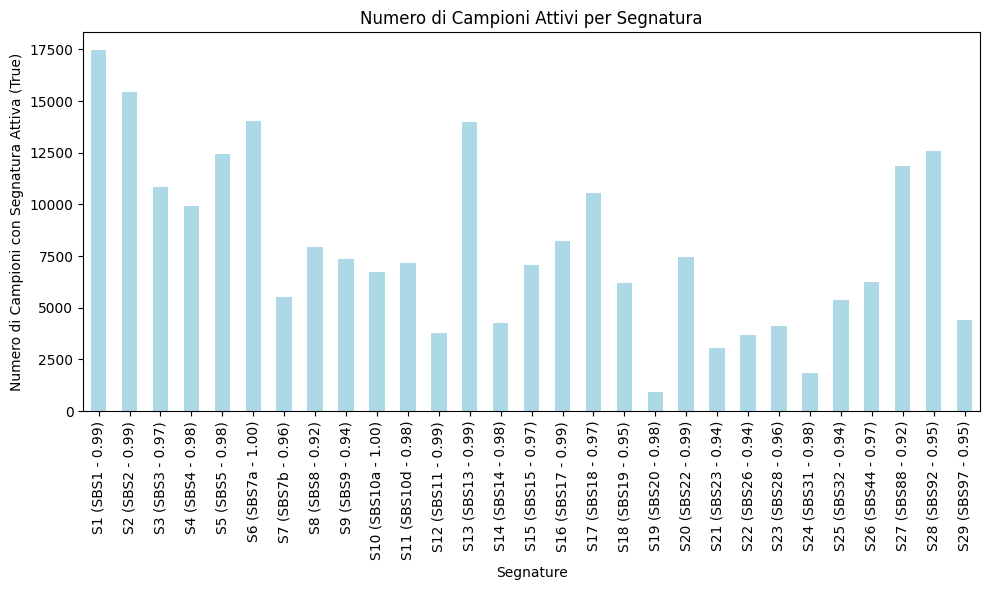

<Figure size 640x480 with 0 Axes>

In [5]:
signature_gt_path = './simulations/ground_truth/bin_exposures.csv'

signature_gt_df = pd.read_csv(signature_gt_path)
signature_gt_df.head()

active_segnature = signature_gt_df.iloc[:, 1:].sum()
plt.figure(figsize=(10, 6))
active_segnature.plot(kind='bar', color='lightblue')
plt.xlabel('Segnature')
plt.ylabel('Numero di Campioni con Segnatura Attiva (True)')
plt.title('Numero di Campioni Attivi per Segnatura')
plt.xticks(rotation=90)  # Ruota le etichette sull'asse X per renderle leggibili
plt.tight_layout()
plt.show()
plt.savefig('./evaluations_graphs/number_of_sample.png')

### Accuratezza per signature, per sample, per run
In questo grafico viene mostrato il livello di accuracy mediato ottenuto per ogni segnatura al variare del livello di sampling, per ogni run

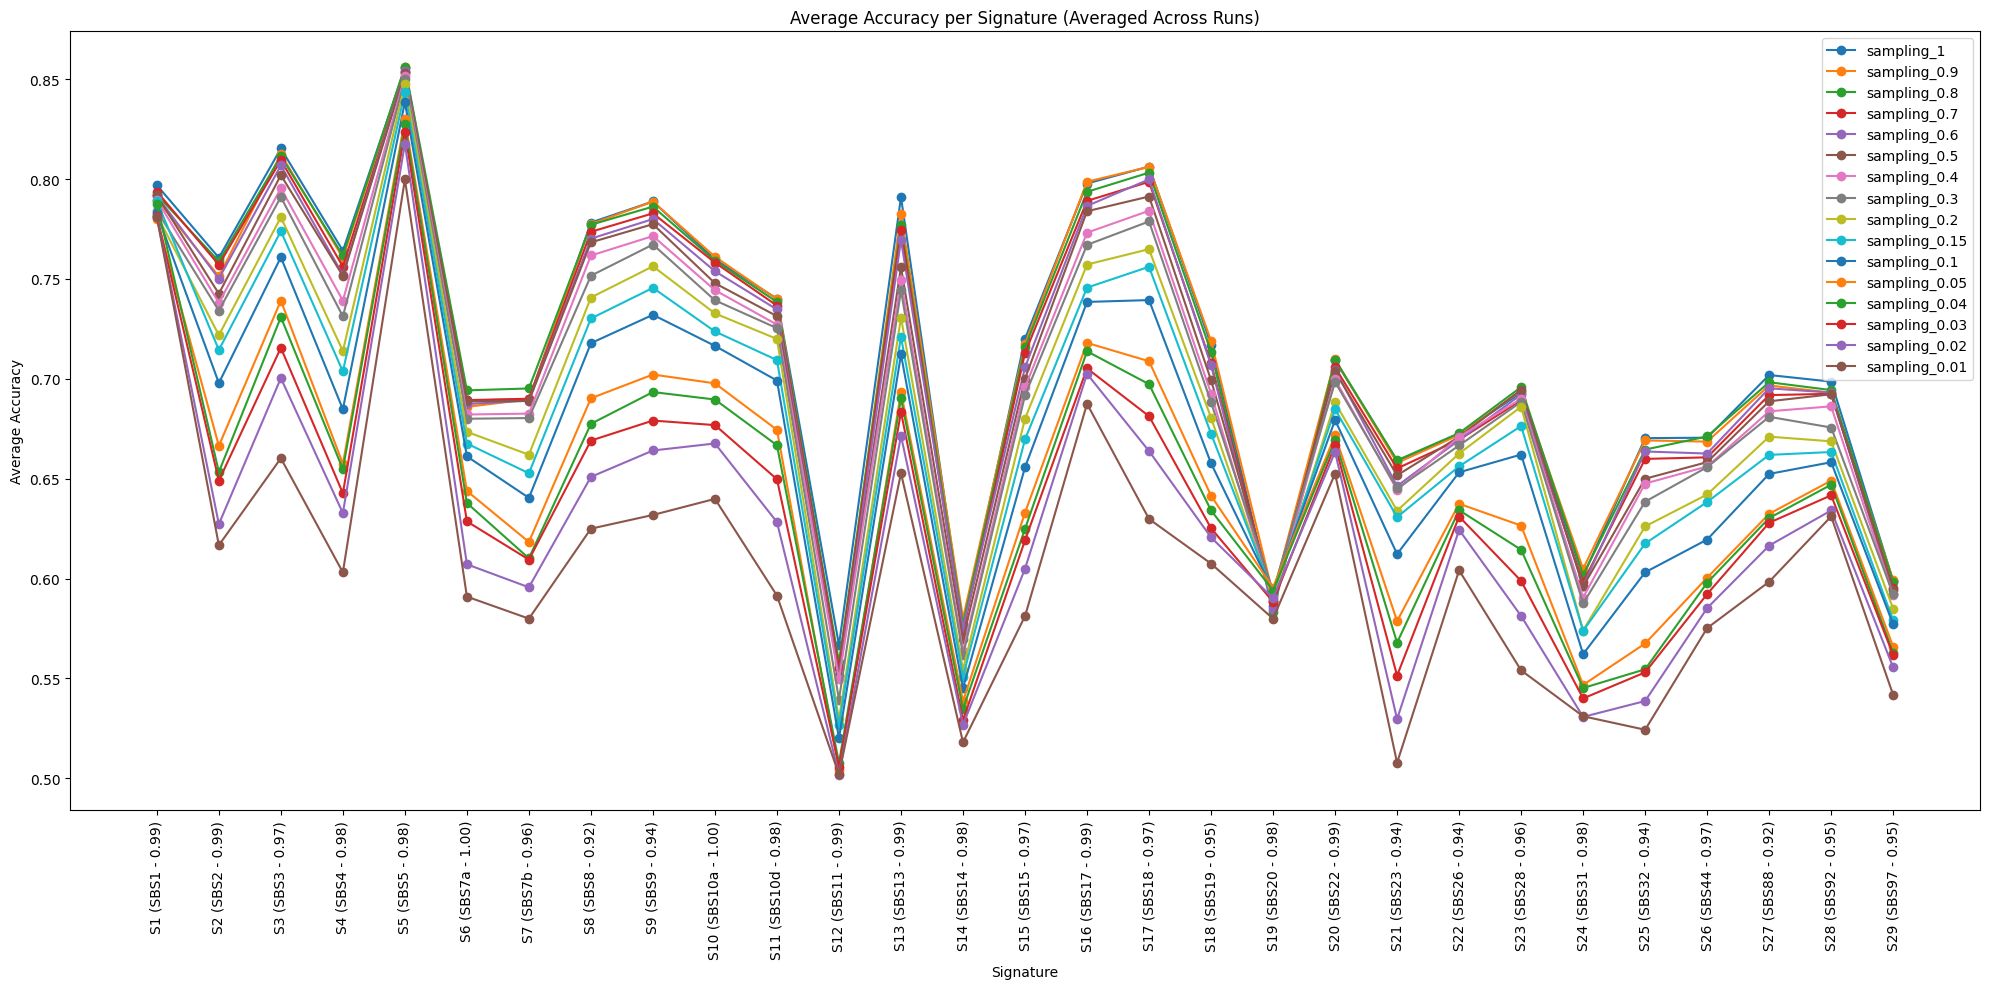

<Figure size 640x480 with 0 Axes>

In [6]:
per_run_accuracy = np.array(per_run_accuracy)
mean_accuracy = np.mean(per_run_accuracy, axis=0)

plt.figure(figsize=(20, 10))

# Plotta la media per ogni campione (dimensione j di per_sample_accuracy)
for j in range(len(mean_accuracy)):
    plt.plot(signature_labels, mean_accuracy[j], marker='o', label=sampling_labels[j])

plt.legend(sampling_labels)
plt.xticks(rotation=90)
plt.ylabel('Average Accuracy')
plt.xlabel('Signature')
plt.title('Average Accuracy per Signature (Averaged Across Runs)')

plt.tight_layout()
plt.show()
plt.savefig('./evaluations_graphs/per_signature_per_sample_average_accuracy.png')



### Accuratezza media per sample per run
In questo grafico venogno 

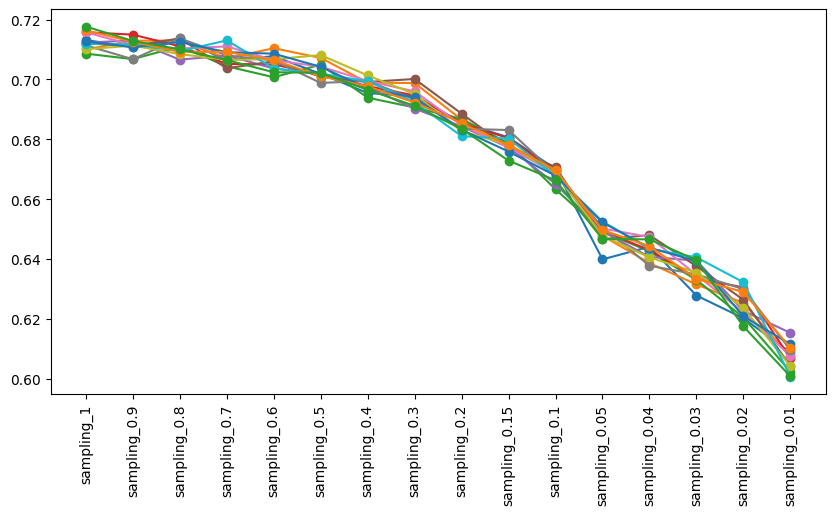

<Figure size 640x480 with 0 Axes>

In [7]:
plt.figure(figsize=(10,5))
for i in range(len(per_run_accuracy)):
    per_sample_mean_accuracy = []
    per_sample_accuracy = per_run_accuracy[i]
    for j in range(len(per_sample_accuracy)):
        per_sample_mean_accuracy.append(np.mean(per_sample_accuracy[j]))

    plt.plot(sampling_labels,per_sample_mean_accuracy, marker='o')
    plt.xticks(rotation=90)

plt.show()
plt.savefig('./evaluations_graphs/toronto_per_sample_average_accuracy_.png')


### Violin-plot

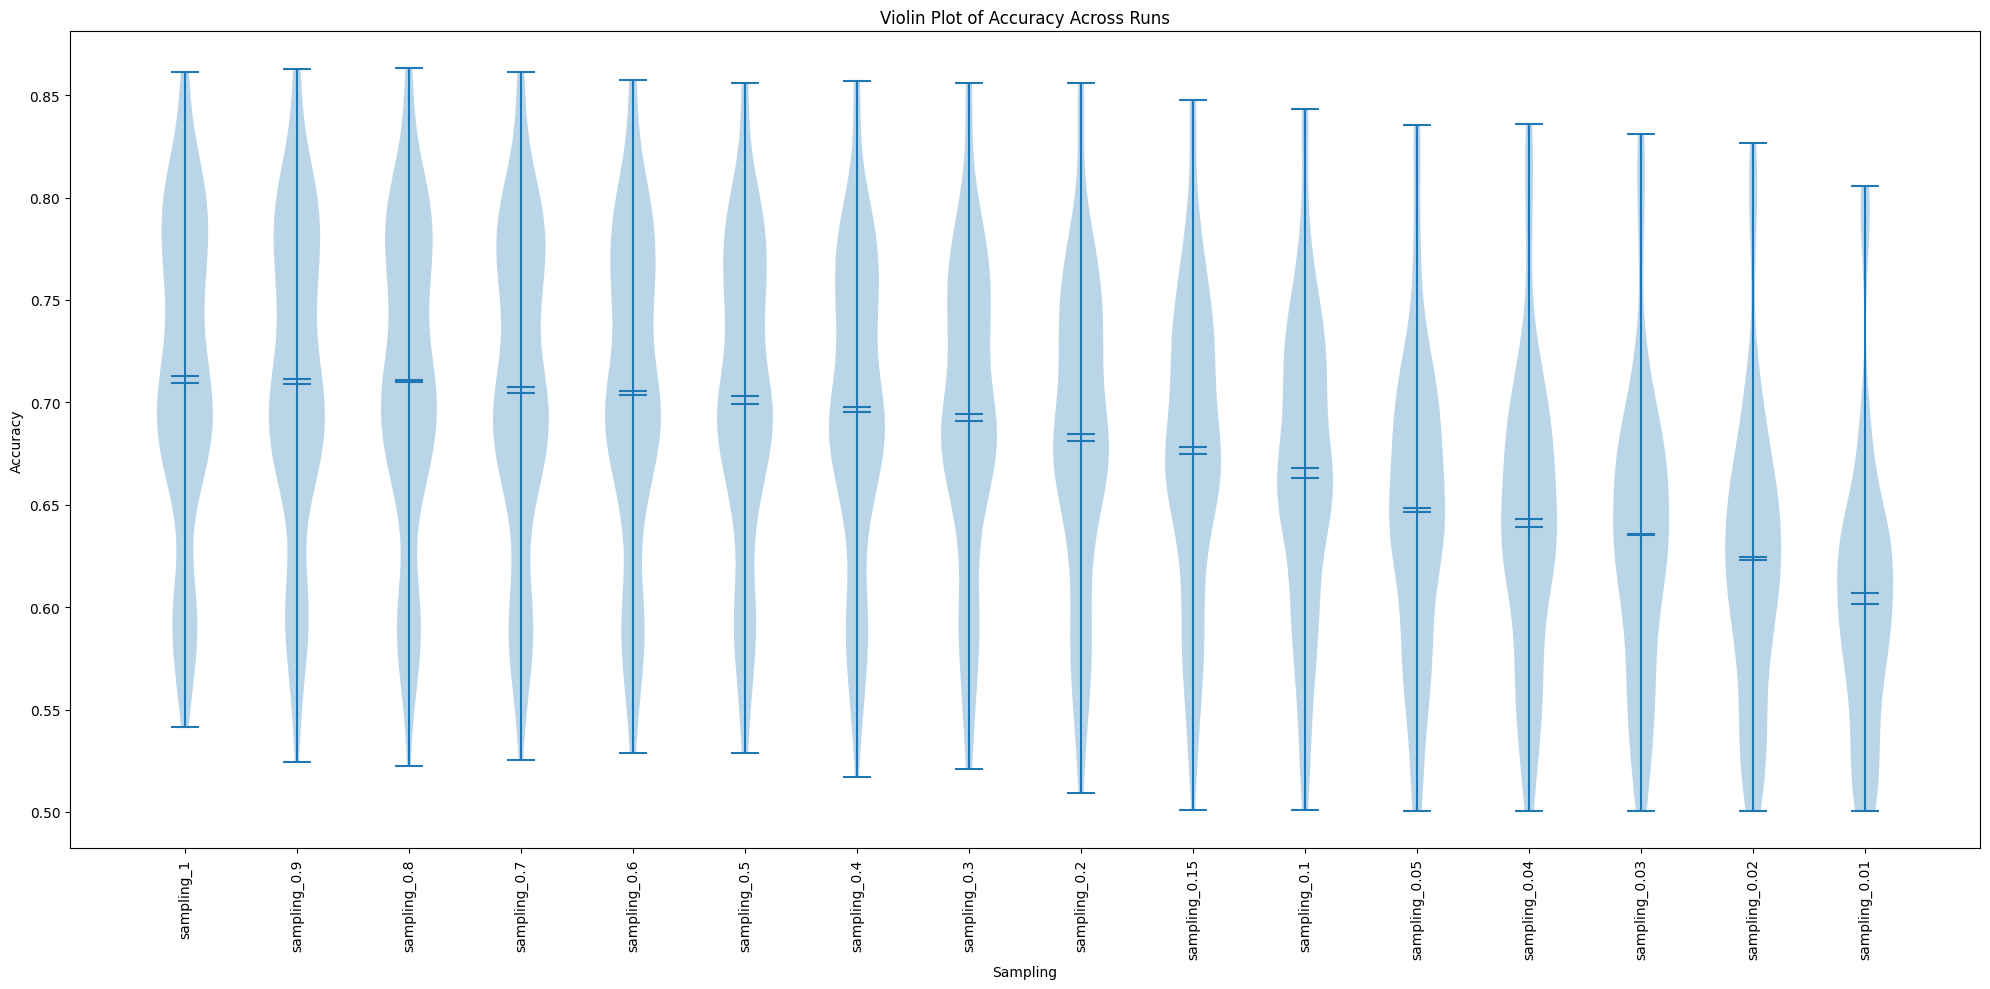

<Figure size 640x480 with 0 Axes>

In [8]:
import numpy as np
import matplotlib.pyplot as plt

per_run_accuracy = np.array(per_run_accuracy)

plt.figure(figsize=(20, 10))
plt.xlabel('Sampling')
plt.xticks(range(1, len(sampling_labels) + 1), sampling_labels, rotation=90)
plt.ylabel('Accuracy')
plt.title('Violin Plot of Accuracy Across Runs')
plt.violinplot([per_run_accuracy[:, j, :].flatten() for j in range(len(sampling_labels))], showmeans=True, showmedians=True, showextrema=True)

plt.tight_layout()
plt.show()
plt.savefig('./evaluations_graphs/toronto_accuracy_violin_plot.png')



# Analysis on the best models

### Best Models

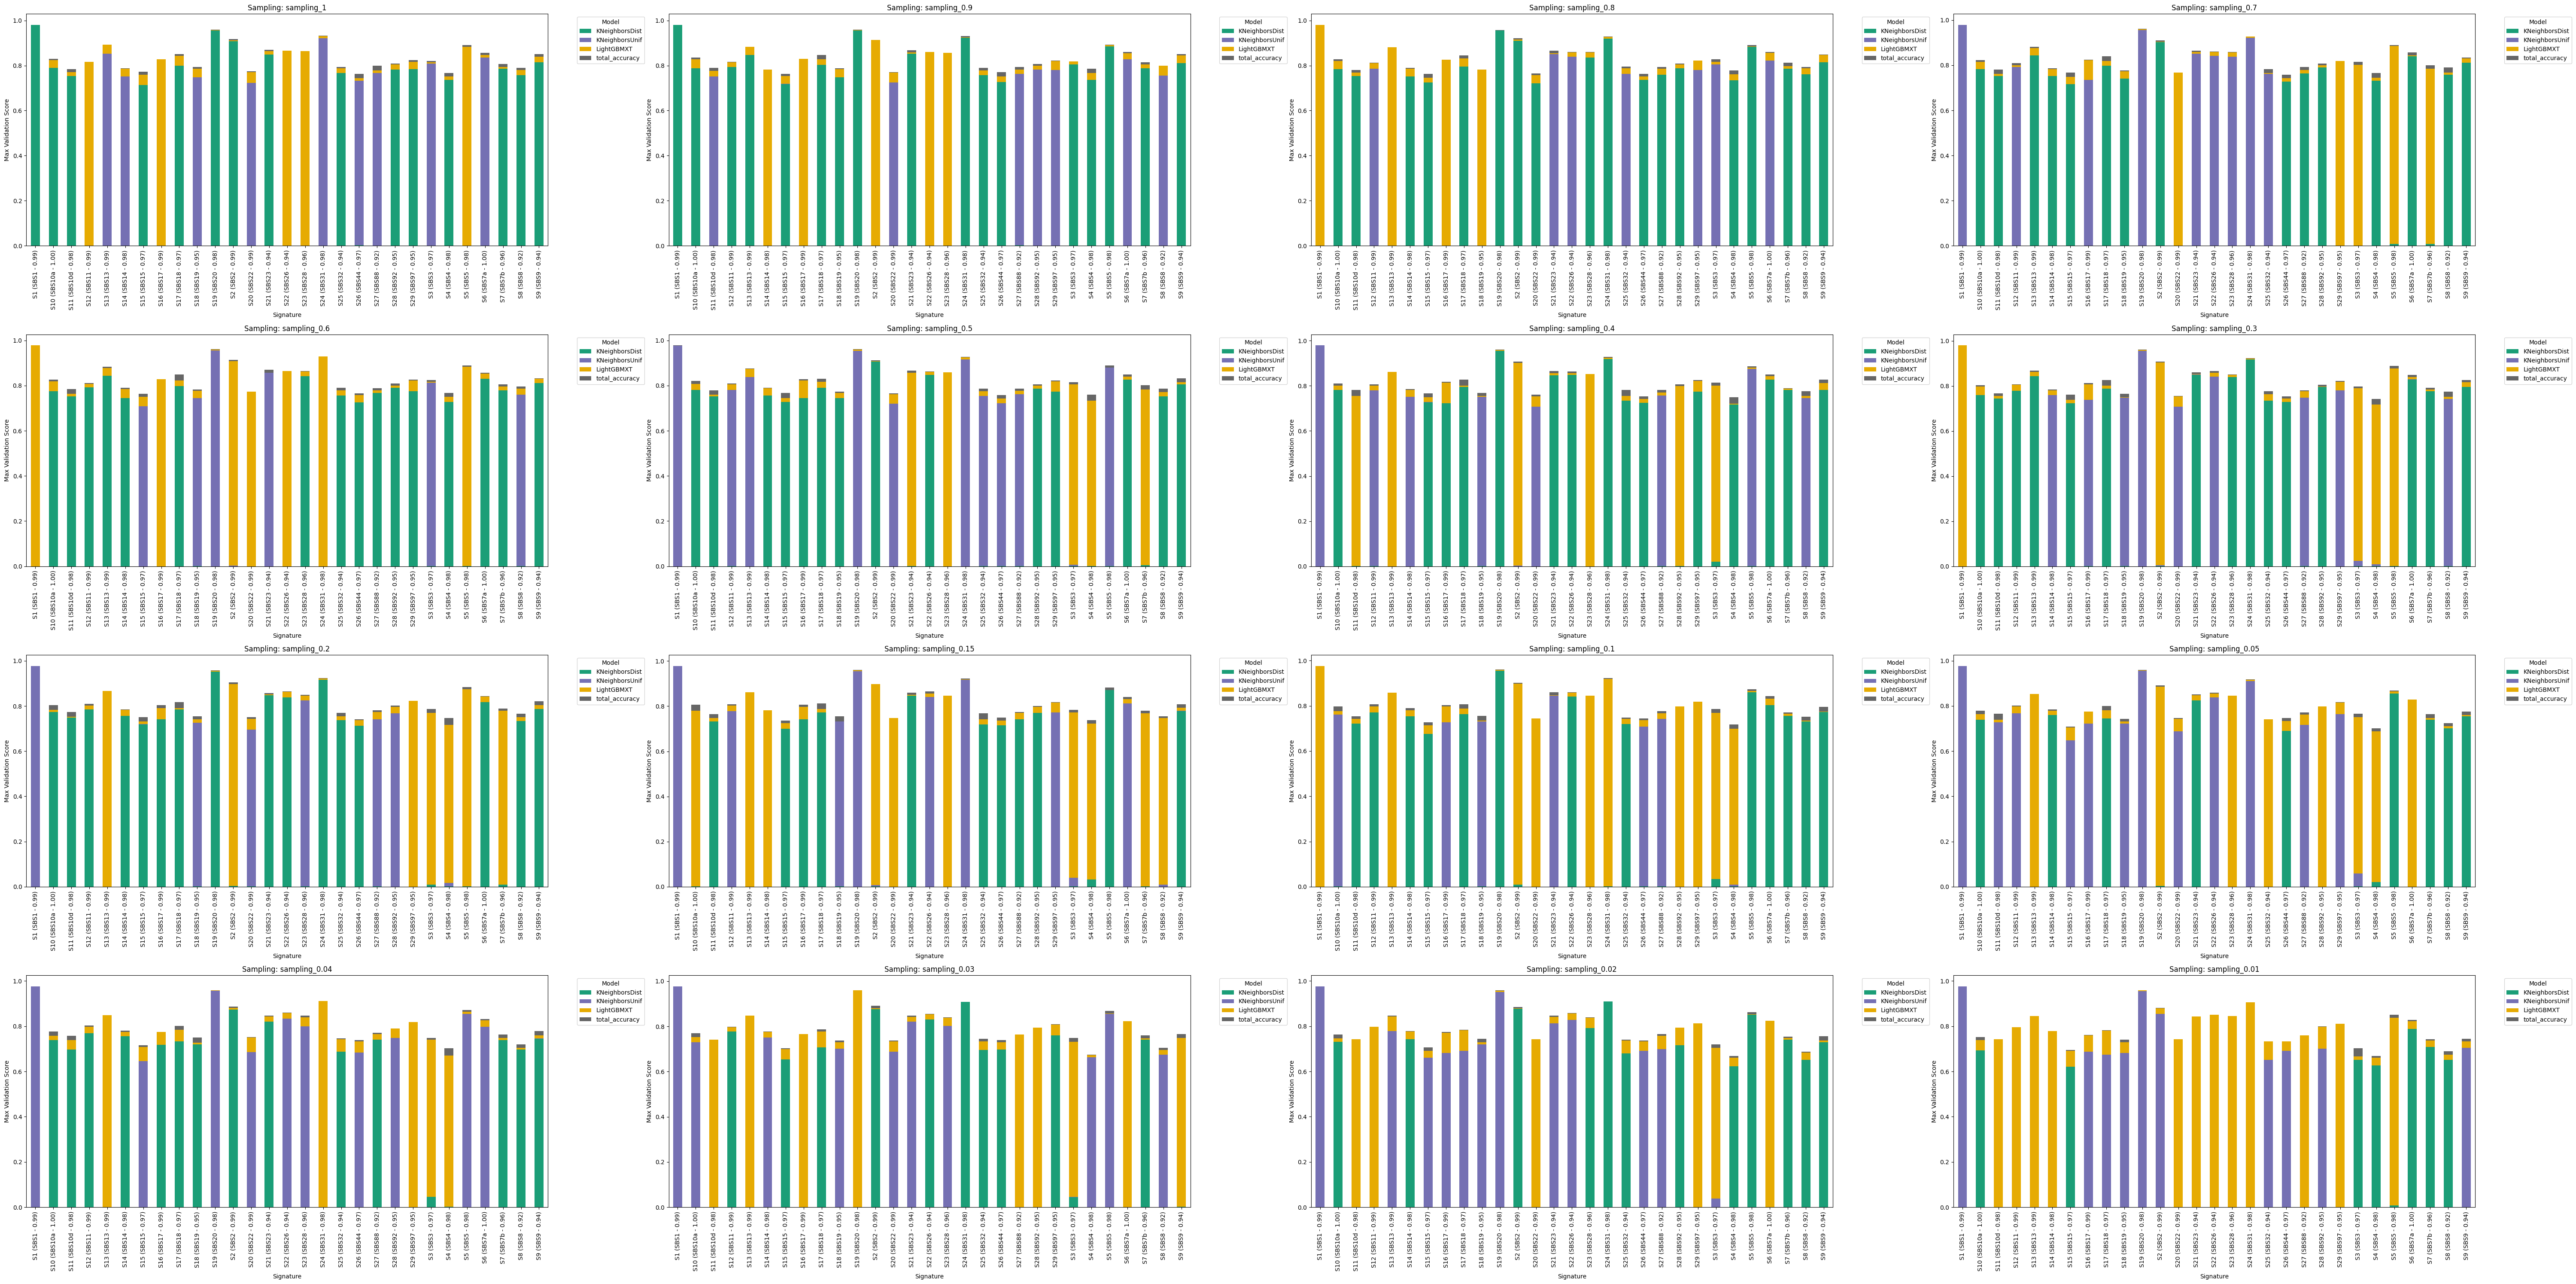

In [9]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Caricamento dati
best_model_df = json.load(open('./results/ensemble_evaluation.json'))

fig, axes = plt.subplots(4, 4, figsize=(60, 30))
axes = axes.flatten()

for plot_idx, sampling in enumerate(sampling_labels):
    rows = []
    for run in run_labels:
        for i, sig in enumerate(signature_labels):
            df = pd.DataFrame(best_model_df[run][sampling][i]['ensemble_info'])
            for _, row in df.iterrows():
                rows.append({
                    'signature': sig,
                    'model': row['model_name'],
                    'val_score': row['val_score']
                })
            rows.append({
                'signature': sig,
                'model': 'total_accuracy',
                'val_score': best_model_df['run_1'][sampling][i]['best_model_val_score']
        })
        break  # solo il primo run

    # Genera il grafico per il subplot corrente
    df_plot = pd.DataFrame(rows)
    processed = []

    for sig, group in df_plot.groupby('signature'):
        sorted_group = group.sort_values('val_score')
        prev = 0
        for _, row in sorted_group.iterrows():
            height = row['val_score'] - prev
            processed.append({
                'signature': sig,
                'model': row['model'],
                'height': height
            })
            prev = row['val_score']

    df_stacked = pd.DataFrame(processed)
    # Pivot e riordino delle colonne
    df_pivot = df_stacked.pivot_table(index='signature', columns='model', values='height', fill_value=0)
    df_pivot.plot(kind='bar', stacked=True, colormap='Dark2', ax=axes[plot_idx])
    axes[plot_idx].set_title(f"Sampling: {sampling}")
    axes[plot_idx].set_ylabel("Max Validation Score")
    axes[plot_idx].set_xlabel("Signature")
    axes[plot_idx].legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.savefig('./evaluations_graphs/toronto_stacked_bar_plot.png')
